In [24]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [25]:
# Load data

df = pd.read_csv("../data/data/credit_card_fraud_10k.csv")

print("Dataset loaded ")
print("Shape:", df.shape)

display(df.head())

Dataset loaded 
Shape: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [26]:
# Quality data check

print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

Duplicate rows:
0

Data types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


Transaction class distribution:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Class percentages:
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


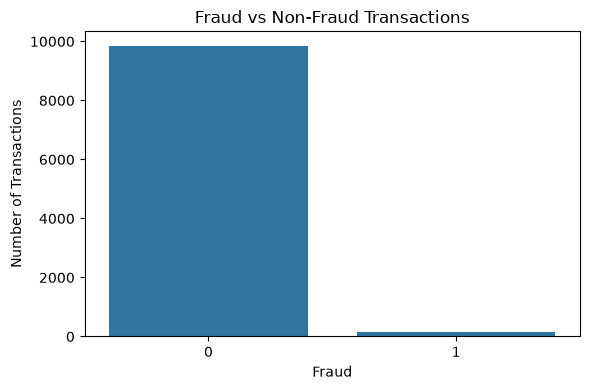

In [27]:
#Check fraud distribution

class_counts = df["is_fraud"].value_counts()

print("Transaction class distribution:")
print(class_counts)

print("\nClass percentages:")
print(
    (df["is_fraud"].value_counts(normalize=True) * 100).round(2)
)

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [28]:
# Encode merchant category

target_column = "is_fraud"
categorical_column = "merchant_category"

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Calculate fraud rate for each merchant category using training data only

category_target_mean = (
    pd.DataFrame({
        categorical_column: X_train[categorical_column],
        target_column: y_train
    })
    .groupby(categorical_column)[target_column]
    .mean()
)

overall_fraud_rate = y_train.mean()

print("Overall training fraud rate:")
print(round(overall_fraud_rate, 4))

print("\nTarget encoding values:")
display(category_target_mean.to_frame("fraud_rate"))

Overall training fraud rate:
0.0151

Target encoding values:


,fraud_rate
merchant_category,
Clothing,0.010962
Electronics,0.009585
Food,0.018574
Grocery,0.021359
Travel,0.015199


In [29]:
# Apply the encoding

X_train = X_train.copy()
X_test = X_test.copy()

X_train["merchant_category_encoded"] = (
    X_train[categorical_column]
    .map(category_target_mean)
    .fillna(overall_fraud_rate)
)

X_test["merchant_category_encoded"] = (
    X_test[categorical_column]
    .map(category_target_mean)
    .fillna(overall_fraud_rate)
)

# Remove original categorical column

X_train = X_train.drop(columns=[categorical_column])
X_test = X_test.drop(columns=[categorical_column])

print("Target encoding completed!")

display(X_train.head())

Target encoding completed!


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_encoded
6402,6403,40.96,6,0,1,82,2,51,0.018574
5802,5803,57.07,6,0,0,42,2,18,0.009585
4131,4132,44.24,0,0,0,26,2,25,0.021359
7626,7627,396.80,23,0,0,97,1,34,0.010962
6046,6047,20.13,0,0,0,91,1,28,0.018574


In [30]:
# Select features

feature_columns = [
    col for col in X_train.columns
    if col != "transaction_id"
]

X_train_model = X_train[feature_columns].copy()
X_test_model = X_test[feature_columns].copy()

print("Features used for modeling:")
print(feature_columns)

Features used for modeling:
['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_encoded']


In [31]:
# Scale the data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

print("Feature scaling completed!")

Feature scaling completed!


In [32]:
# Handle class imbalance

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


,Before SMOTE,After SMOTE
is_fraud,,
0,7879,7879
1,121,7879


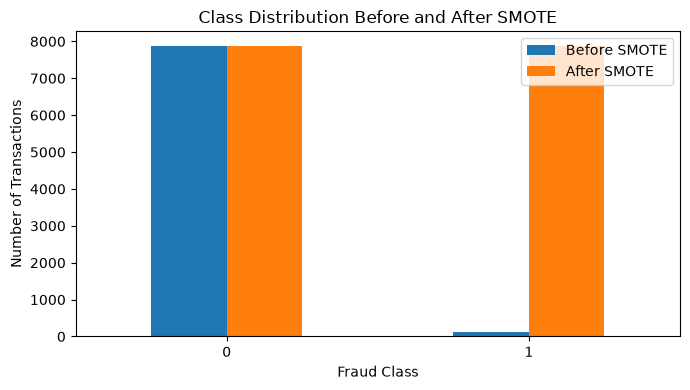

In [33]:
# Compare before and after SMOTE

before = y_train.value_counts().sort_index()
after = pd.Series(y_train_smote).value_counts().sort_index()

comparison = pd.DataFrame({
    "Before SMOTE": before,
    "After SMOTE": after
})

display(comparison)

comparison.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Class Distribution Before and After SMOTE")
plt.xlabel("Fraud Class")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
# Isolation Forest

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

isolation_predictions = isolation_forest.fit_predict(
    X_train_scaled
)

# -1 means outlier
#  1 means normal

df_train_outliers = X_train.copy()

df_train_outliers["isolation_forest"] = isolation_predictions

outlier_count = (
    df_train_outliers["isolation_forest"] == -1
).sum()

normal_count = (
    df_train_outliers["isolation_forest"] == 1
).sum()

print("Isolation Forest results:")
print("Normal transactions:", normal_count)
print("Outliers:", outlier_count)

Isolation Forest results:
Normal transactions: 5470
Outliers: 2530


In [35]:
# Local Outlier Factor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto"
)

lof_predictions = lof.fit_predict(
    X_train_scaled
)

df_train_outliers["lof"] = lof_predictions

lof_outliers = (
    df_train_outliers["lof"] == -1
).sum()

lof_normal = (
    df_train_outliers["lof"] == 1
).sum()

print("Local Outlier Factor results:")
print("Normal transactions:", lof_normal)
print("Outliers:", lof_outliers)

Local Outlier Factor results:
Normal transactions: 7990
Outliers: 10


In [36]:
# Compare the two methods

outlier_comparison = pd.DataFrame({
    "Isolation_Forest": df_train_outliers["isolation_forest"],
    "LOF": df_train_outliers["lof"]
})

print("Outlier detection comparison:")

display(
    outlier_comparison.value_counts().reset_index(
        name="Count"
    )
)

Outlier detection comparison:


,Isolation_Forest,LOF,Count
0,1,1,5470
1,-1,1,2520
2,-1,-1,10


In [37]:
# Check common outliers

both_outliers = (
    (df_train_outliers["isolation_forest"] == -1) &
    (df_train_outliers["lof"] == -1)
)

print(
    "Transactions identified as outliers by both methods:",
    both_outliers.sum()
)

Transactions identified as outliers by both methods: 10


In [38]:
# Prepare final training data

X_train_final = pd.DataFrame(
    X_train_scaled,
    columns=feature_columns,
    index=X_train.index
)

X_test_final = pd.DataFrame(
    X_test_scaled,
    columns=feature_columns,
    index=X_test.index
)

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

display(X_train_final.head())

Final training shape: (8000, 8)
Final testing shape: (2000, 8)


,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_encoded
6402,-0.769255,-0.808001,-0.330549,3.280961,0.930866,-0.005472,0.507084,0.780041
5802,-0.677049,-0.808001,-0.330549,-0.304789,-0.930308,-0.005472,-1.696975,-1.253028
4131,-0.750482,-1.675479,-0.330549,-0.304789,-1.674777,-0.005472,-1.229448,1.409961
7626,1.267417,1.649853,-0.330549,-0.304789,1.628806,-0.700342,-0.628341,-0.941469
6046,-0.888477,-1.675479,-0.330549,-0.304789,1.349630,-0.700342,-1.029079,0.780041


In [39]:
# Save processed datasets

import os

os.makedirs("../results", exist_ok=True)

In [40]:
# Save the processed data

X_train_final.to_csv(
    "../results/X_train_processed.csv",
    index=False
)

X_test_final.to_csv(
    "../results/X_test_processed.csv",
    index=False
)

y_train.to_csv(
    "../results/y_train.csv",
    index=False
)

y_test.to_csv(
    "../results/y_test.csv",
    index=False
)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!


In [41]:
# Save Smote data

smote_train = pd.DataFrame(
    X_train_smote,
    columns=feature_columns
)

smote_train["is_fraud"] = y_train_smote.values

smote_train.to_csv(
    "../results/smote_training_data.csv",
    index=False
)

print("SMOTE dataset saved successfully!")
print("Shape:", smote_train.shape)

SMOTE dataset saved successfully!
Shape: (15758, 9)


In [42]:
# Save outlier detection results

outlier_results = pd.DataFrame({
    "isolation_forest": isolation_predictions,
    "lof": lof_predictions
})

outlier_results.to_csv(
    "../results/outlier_detection.csv",
    index=False
)

print("Outlier results saved successfully!")

Outlier results saved successfully!


Phase 1 Final Summary


The dataset was prepared for machine learning by applying several
feature engineering and data preparation techniques.

- Merchant category was converted using target encoding.
- Class imbalance was addressed using SMOTE.
- Isolation Forest was used to identify global anomalies.
- Local Outlier Factor was used to identify local anomalies.
- Numerical features were standardized before applying the
  outlier detection methods.
- Training and testing data were kept separate to reduce the risk
  of data leakage.

The processed datasets and analysis results were saved in the
results folder for use in the next phase.